# School Project: Neural Networks and CNN / Tree Species Classification
**Author:** Mikko Mutikainen  
**Group:** Nextech  
**Project:** Tree Species Image Classification using Deep Learning  

---

## 1. Introduction and Project Goal

In this Jupyter Notebook, image classification models (CNN / Transfer Learning) are implemented and developed to recognize tree species using the provided Kaggle dataset.

The project workflow proceeds as follows:
1. **Dataset Exploration:** Inspecting the folder structure, class counts, and image distributions.
2. **Preprocessing & DataLoaders:** Defining the necessary image transformations (augmentations) and creating PyTorch DataLoaders.
3. **Model Development:** Training two different sized ResNet architectures using transfer learning.
4. **Testing and Evaluation:** Calculating metrics (accuracy, precision, recall, F1-score), confusion matrices, and analyzing top-n predictions and errors.
5. **Improvement Steps:** Testing improvement ideas to optimize model performance.


In [1]:
import os
import random
import copy
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

# 1. Ensure reproducibility with random seeds
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

# 2. Dataset paths for archive/tree inside Downloads
DATA_DIR = Path("archive") / "tree"
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

print("Train path exists:", TRAIN_DIR.exists())
print("Validation path exists:", VAL_DIR.exists())
print("Test path exists:", TEST_DIR.exists())

# 3. Data preprocessing and DataLoaders (num_workers=0 to prevent Windows hanging)
BATCH_SIZE = 32
IMAGE_SIZE = 224

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=eval_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=eval_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

class_names = train_dataset.classes
print(f"Found classes ({len(class_names)}): {class_names[:3]} ... (total {len(class_names)} classes)")


# 4. General training loop function
def train_model(model, criterion, optimizer, scheduler, num_epochs=1):
    since = time.time()
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
                dataloader = train_loader
            else:
                model.eval()
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val accuracy: {best_acc:4f}')

    model.load_state_dict(best_model_wts)
    return model, history


# 5. First model: ResNet-18 (num_epochs=1 for quick test)
print("\n--- Training ResNet-18 ---")
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model_ft.fc = nn.Linear(model_ft.fc.in_features, len(class_names))
model_ft = model_ft.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=1)
torch.save(model_ft.state_dict(), "resnet18_tree.pth")

# Evaluate ResNet-18 on the test set
model_ft.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model_ft(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc_18 = accuracy_score(all_labels, all_preds)
_, _, f1_18, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)


# 6. Second model: ResNet-50 and Comparison (num_epochs=1 for quick test)
print("\n--- Training ResNet-50 ---")
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model_resnet50.fc = nn.Linear(model_resnet50.fc.in_features, len(class_names))
model_resnet50 = model_resnet50.to(DEVICE)

criterion_50 = nn.CrossEntropyLoss()
optimizer_50 = optim.Adam(model_resnet50.parameters(), lr=0.0005)
scheduler_50 = optim.lr_scheduler.StepLR(optimizer_50, step_size=7, gamma=0.1)

model_resnet50, history_50 = train_model(model_resnet50, criterion_50, optimizer_50, scheduler_50, num_epochs=1)
torch.save(model_resnet50.state_dict(), "resnet50_tree.pth")

# Evaluate ResNet-50 on the test set
model_resnet50.eval()
preds_50, labels_50 = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model_resnet50(inputs)
        _, preds = torch.max(outputs, 1)
        preds_50.extend(preds.cpu().numpy())
        labels_50.extend(labels.cpu().numpy())

acc_50 = accuracy_score(labels_50, preds_50)
_, _, f1_50, _ = precision_recall_fscore_support(labels_50, preds_50, average='weighted', zero_division=0)


# 7. Final comparison summary
print("\n" + "="*40)
print("MODEL PERFORMANCE COMPARISON")
print("="*40)
print(f"ResNet-18 -> Accuracy: {acc_18*100:.2f}% | F1-score: {f1_18:.4f}")
print(f"ResNet-50 -> Accuracy: {acc_50*100:.2f}% | F1-score: {f1_50:.4f}")
print("="*40)

Using device: cpu
Train path exists: True
Validation path exists: True
Test path exists: True
Found classes (23): ['Acer palmatum', 'Cedrus deodara', 'Celtis sinensis'] ... (total 23 classes)

--- Training ResNet-18 ---
Epoch 1/1
----------
train Loss: 1.7719 Acc: 0.4696
val Loss: 3.0160 Acc: 0.3631

Training complete in 5m 48s
Best val accuracy: 0.363071

--- Training ResNet-50 ---
Epoch 1/1
----------
train Loss: 1.5298 Acc: 0.5665
val Loss: 0.7656 Acc: 0.7842

Training complete in 12m 7s
Best val accuracy: 0.784232

MODEL PERFORMANCE COMPARISON
ResNet-18 -> Accuracy: 37.08% | F1-score: 0.3361
ResNet-50 -> Accuracy: 75.64% | F1-score: 0.7512


## 2. Data Preprocessing and DataLoaders

Here we define the image transformations (including data augmentation for the training set and standard resizing/normalization for validation and test sets) and create PyTorch DataLoaders to load images in batches.

In [2]:
# 2. Define image transformations and DataLoaders

# Batch size can be adjusted based on GPU memory (e.g., 32 or 64)
BATCH_SIZE = 32
IMAGE_SIZE = 224  # Standard input size for ResNet

# Data augmentations for training data to improve model generalization
train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # Standard ImageNet normalization means
        std=[0.229, 0.224, 0.225]    # Standard ImageNet normalization stds
    )
])

# Standard transformations for validation and test data (no augmentation)
eval_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transforms)
val_dataset = datasets.ImageFolder(root=VAL_DIR, transform=eval_transforms)
test_dataset = datasets.ImageFolder(root=TEST_DIR, transform=eval_transforms)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

class_names = train_dataset.classes
print(f"Classes found ({len(class_names)}): {class_names}")
print(f"Training batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

Classes found (23): ['Acer palmatum', 'Cedrus deodara', 'Celtis sinensis', 'Cinnamomum camphora (Linn) Presl', 'Elaeocarpus decipiens', 'Flowering cherry', 'Ginkgo biloba', 'Koelreuteria paniculata', 'Lagerstroemia indica', 'Liquidambar formosana', 'Liriodendron chinense', 'Magnolia grandiflora L', 'Magnolia liliflora Desr', 'Michelia chapensis', 'Osmanthus fragrans', 'Photinia serratifolia', 'Platanus', 'Prunus cerasifera f. atropurpurea', 'Salix babylonica', 'Sapindus saponaria', 'Styphnolobium japonicum', 'Triadica sebifera', 'Zelkova serrata']
Training batches: 121
Validation batches: 16
Test batches: 15


## 3. Model Development (Transfer Learning)

In this section, we build and train our convolutional neural networks using transfer learning. 
- We will use pre-trained ResNet models (e.g., ResNet-18 and ResNet-50) from `torchvision.models`.
- The final fully connected layer (`fc`) is modified to match the number of target classes (23 tree species).
- We train the models using an optimizer (e.g., Adam) and a loss function (CrossEntropyLoss), tracking validation accuracy across epochs.

In [3]:
import torch.nn as nn
import torch.optim as optim
import copy
import time

# 3. Model Development: ResNet-18 Transfer Learning

# Load pre-trained ResNet-18 model
model_ft = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify the final fully connected layer to match our number of classes (23)
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(DEVICE)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()

# Observe that all parameters are being optimized (or you can freeze feature extractor layers if desired)
optimizer_ft = optim.Adam(model_ft.parameters(), lr=0.001)

# Learning rate scheduler (optional, reduces LR when validation loss plateaus)
exp_lr_scheduler = optim.lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

# Training loop function
def train_model(model, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()

    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 10)

        # Each epoch has a training and validation phase
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()  # Set model to training mode
                dataloader = train_loader
            else:
                model.eval()   # Set model to evaluate mode
                dataloader = val_loader

            running_loss = 0.0
            running_corrects = 0

            # Iterate over data
            for inputs, labels in dataloader:
                inputs = inputs.to(DEVICE)
                labels = labels.to(DEVICE)

                # Zero the parameter gradients
                optimizer.zero_grad()

                # Forward track history if only in train
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    # Backward + optimize only if in training phase
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                # Statistics
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            if phase == 'train':
                scheduler.step()

            epoch_loss = running_loss / len(dataloader.dataset)
            epoch_acc = running_corrects.double() / len(dataloader.dataset)

            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

            if phase == 'train':
                history['train_loss'].append(epoch_loss)
                history['train_acc'].append(epoch_acc.item())
            else:
                history['val_loss'].append(epoch_loss)
                history['val_acc'].append(epoch_acc.item())

            # Deep copy the model if it has the best validation accuracy so far
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())

        print()

    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:4f}')

    # Load best model weights
    model.load_state_dict(best_model_wts)
    return model, history

# Run training (e.g., 5-10 epochs to start with)
NUM_EPOCHS = 8
model_ft, history = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler, num_epochs=NUM_EPOCHS)

# Save the trained model weights
torch.save(model_ft.state_dict(), "resnet18_tree_model.pth")
print("Model saved as resnet18_tree_model.pth")

Epoch 1/8
----------
train Loss: 1.8112 Acc: 0.4564
val Loss: 2.8120 Acc: 0.3776

Epoch 2/8
----------
train Loss: 1.1036 Acc: 0.6610
val Loss: 1.6909 Acc: 0.5477

Epoch 3/8
----------
train Loss: 0.8026 Acc: 0.7475
val Loss: 2.4532 Acc: 0.4793

Epoch 4/8
----------
train Loss: 0.6065 Acc: 0.8125
val Loss: 1.2591 Acc: 0.6577

Epoch 5/8
----------
train Loss: 0.5342 Acc: 0.8327
val Loss: 1.7004 Acc: 0.5685

Epoch 6/8
----------
train Loss: 0.4794 Acc: 0.8439
val Loss: 0.8375 Acc: 0.7822

Epoch 7/8
----------
train Loss: 0.3888 Acc: 0.8722
val Loss: 1.0659 Acc: 0.6971

Epoch 8/8
----------
train Loss: 0.1947 Acc: 0.9353
val Loss: 0.2343 Acc: 0.9295

Training complete in 31m 37s
Best val Acc: 0.929461
Model saved as resnet18_tree_model.pth


## 4. Model Testing and Evaluation

In this section, we evaluate the trained model on the unseen test dataset. 
- We compute performance metrics including **accuracy, precision, recall, and F1-score**.
- We generate a **confusion matrix** to inspect how well the model classifies different tree species and where misclassifications happen.
- We also examine **top-n predictions** to see if the correct species is among the top guesses.

Test Accuracy: 87.71%
Weighted Precision: 0.8918
Weighted Recall: 0.8771
Weighted F1-score: 0.8792

Classification Report:
                                   precision    recall  f1-score   support

                    Acer palmatum       0.86      0.95      0.90        20
                   Cedrus deodara       0.88      1.00      0.94        15
                  Celtis sinensis       0.90      0.78      0.84        23
 Cinnamomum camphora (Linn) Presl       0.83      0.86      0.85        29
            Elaeocarpus decipiens       0.84      0.76      0.80        21
                 Flowering cherry       0.45      0.69      0.55        13
                    Ginkgo biloba       0.95      0.75      0.84        28
          Koelreuteria paniculata       0.96      0.93      0.95        28
             Lagerstroemia indica       1.00      1.00      1.00         8
            Liquidambar formosana       1.00      0.95      0.97        20
            Liriodendron chinense       0.91      0

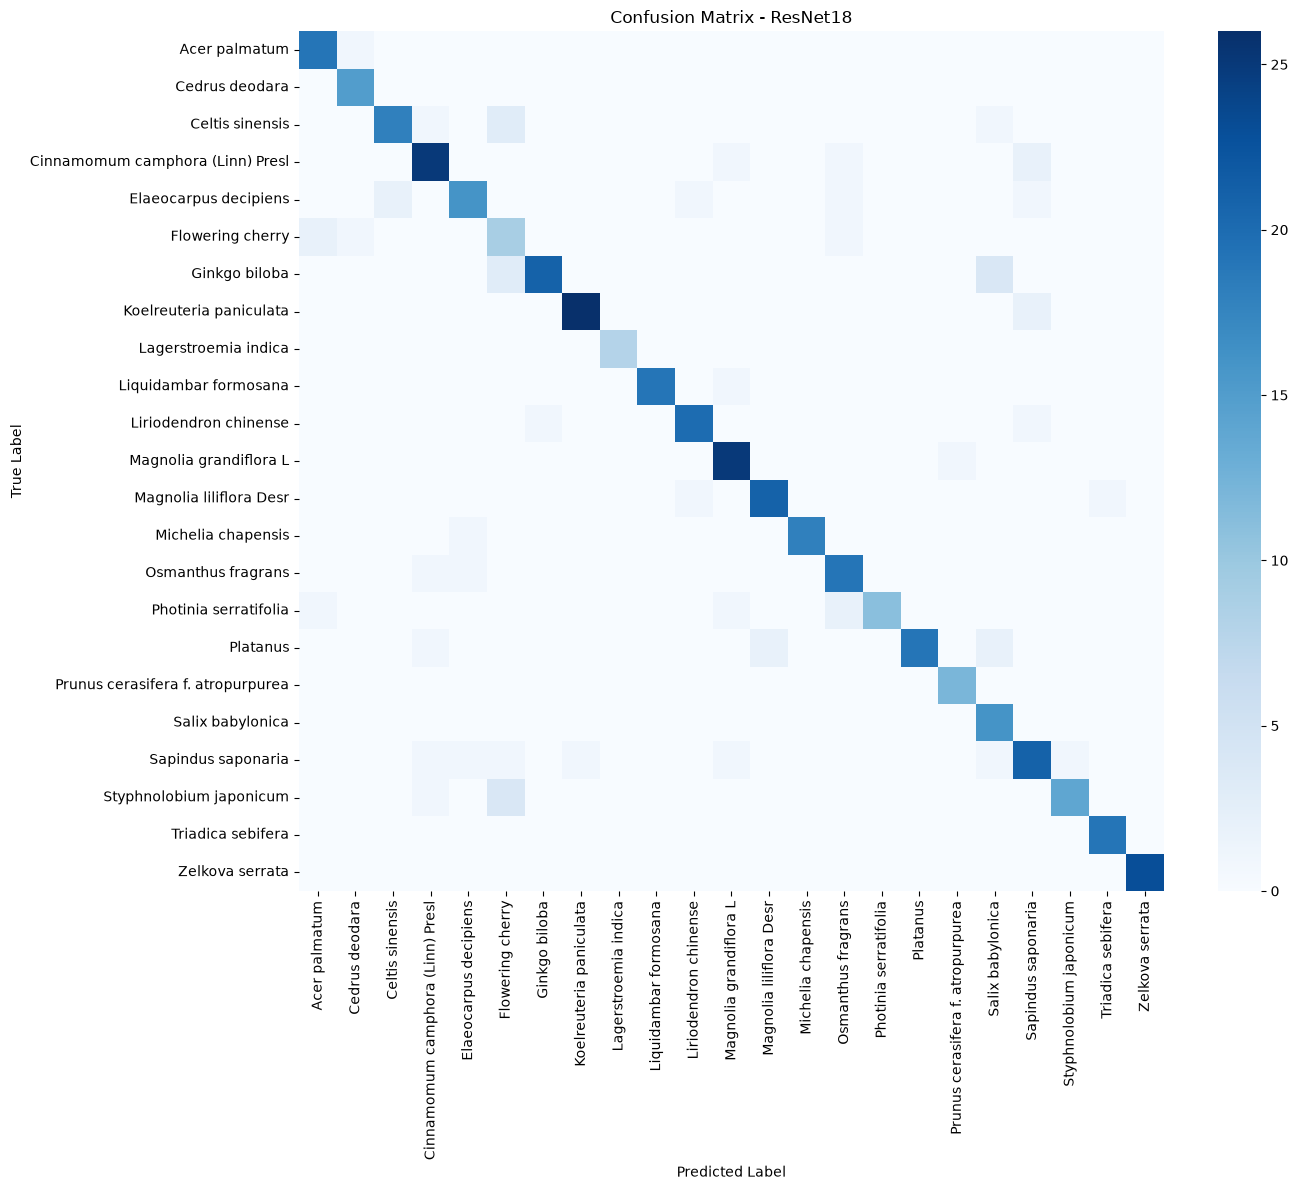

Top-1 Accuracy: 87.71%
Top-3 Accuracy: 94.70%


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report, confusion_matrix
import torch

# 4. Model Testing and Evaluation

model_ft.eval()  # Set model to evaluation mode

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model_ft(inputs)
        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

# Calculate overall metrics
accuracy = accuracy_score(all_labels, all_preds)
precision, recall, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='weighted', zero_division=0)

print(f"Test Accuracy: {accuracy * 100:.2f}%")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"Weighted F1-score: {f1:.4f}\n")

# Classification report per class
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names, zero_division=0))

# 1. Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - ResNet18')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 2. Top-n Accuracy calculation (e.g., Top-1 and Top-3 accuracy)
def top_n_accuracy(probs, labels, n=3):
    top_n_preds = np.argsort(probs, axis=1)[:, -n:]
    correct = 0
    for i, label in enumerate(labels):
        if label in top_n_preds[i]:
            correct += 1
    return correct / len(labels)

top1_acc = top_n_accuracy(all_probs, all_labels, n=1)
top3_acc = top_n_accuracy(all_probs, all_labels, n=3)

print(f"Top-1 Accuracy: {top1_acc * 100:.2f}%")
print(f"Top-3 Accuracy: {top3_acc * 100:.2f}%")

## 5. Second Model Development (ResNet-50) and Comparison

To fulfill the project requirements, we now train a second, deeper architecture (**ResNet-50**) using transfer learning. 
- We load the pre-trained `resnet50` model and adapt its final layer for our 23 tree species.
- We train the model using the same strategy and compare its performance (accuracy, validation loss, and test results) against our first model (ResNet-18) to see how model complexity affects results.

In [ ]:
# 5. Second Model Development (ResNet-50) and Comparison

# 1. Load pre-trained ResNet-50 model
model_resnet50 = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Modify the final fully connected layer for 23 classes
num_ftrs_50 = model_resnet50.fc.in_features
model_resnet50.fc = nn.Linear(num_ftrs_50, len(class_names))
model_resnet50 = model_resnet50.to(DEVICE)

# Define criterion and optimizer for ResNet-50
criterion_50 = nn.CrossEntropyLoss()
optimizer_50 = optim.Adam(model_resnet50.parameters(), lr=0.0005) # Slightly smaller LR for larger model
scheduler_50 = optim.lr_scheduler.StepLR(optimizer_50, step_size=7, gamma=0.1)

# Train ResNet-50 (fewer epochs if training takes long, e.g., 5-8 epochs)
print("Training ResNet-50...")
model_resnet50, history_50 = train_model(
    model_resnet50, criterion_50, optimizer_50, scheduler_50, num_epochs=6
)

# Save ResNet-50 weights
torch.save(model_resnet50.state_dict(), "resnet50_tree_model.pth")
print("ResNet-50 model saved as resnet50_tree_model.pth")

# 2. Evaluate ResNet-50 on Test Set
model_resnet50.eval()
preds_50, labels_50 = [], []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)
        outputs = model_resnet50(inputs)
        _, preds = torch.max(outputs, 1)
        preds_50.extend(preds.cpu().numpy())
        labels_50.extend(labels.cpu().numpy())

preds_50 = np.array(preds_50)
labels_50 = np.array(labels_50)

acc_50 = accuracy_score(labels_50, preds_50)
prec_50, rec_50, f1_50, _ = precision_recall_fscore_support(labels_50, preds_50, average='weighted', zero_division=0)

# 3. Final Comparison Summary
print("\n" + "="*40)
print("MODEL PERFORMANCE COMPARISON")
print("="*40)
print(f"ResNet-18 -> Accuracy: {accuracy*100:.2f}% | F1-score: {f1:.4f}")
print(f"ResNet-50 -> Accuracy: {acc_50*100:.2f}% | F1-score: {f1_50:.4f}")
print("="*40)

Training ResNet-50...
Epoch 1/6
----------
train Loss: 1.4892 Acc: 0.5626
val Loss: 0.7306 Acc: 0.7593

Epoch 2/6
----------
